
Linear Regression From Scratch
================================
Implemented using only NumPy — no scikit-learn for the model itself.
Covers:
  - Gradient Descent (Batch)
  - MSE Loss
  - Training curve plot
  - Comparison with scikit-learn result
  - Prediction on new data


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.metrics import mean_squared_error, r2_score


# Linear Regression using Batch Gradient Descent.

*Math:*
- Prediction : y_hat = X @ w + b
- MSE Loss   : L = (1/n) * sum((y_hat - y)^2)
- Gradient w : dL/dw = (2/n) * X.T @ (y_hat - y)
- Gradient b : dL/db = (2/n) * sum(y_hat - y)
- Update     : w = w - lr * dL/dw
                b = b - lr * dL/db


In [2]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr      = learning_rate
        self.epochs  = epochs
        self.weights = None
        self.bias    = None
        self.losses  = []          # track MSE every epoch

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias to zero
        self.weights = np.zeros(n_features)
        self.bias    = 0.0

        for epoch in range(self.epochs):

            # ── Forward pass ──────────────────
            y_hat = X @ self.weights + self.bias

            # ── MSE Loss ──────────────────────
            loss = np.mean((y_hat - y) ** 2)
            self.losses.append(loss)

            # ── Gradients ─────────────────────
            dw = (2 / n_samples) * (X.T @ (y_hat - y))
            db = (2 / n_samples) * np.sum(y_hat - y)

            # ── Update parameters ─────────────
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Print progress every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1:4d}/{self.epochs}  |  MSE Loss: {loss:.4f}")

        return self

    def predict(self, X):
        return X @ self.weights + self.bias

    def mse(self, y_true, y_pred):
        return np.mean((y_pred - y_true) ** 2)

    def r2(self, y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / ss_tot)

In [3]:
print("=" * 50)
print("  Linear Regression From Scratch — Diabetes")
print("=" * 50)

data    = load_diabetes()
X, y    = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling — crucial for gradient descent to converge
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nDataset  : Diabetes (sklearn built-in)")
print(f"Features : {X.shape[1]}")
print(f"Train    : {X_train.shape[0]} samples")
print(f"Test     : {X_test.shape[0]} samples")


  Linear Regression From Scratch — Diabetes

Dataset  : Diabetes (sklearn built-in)
Features : 10
Train    : 353 samples
Test     : 89 samples


In [4]:
print("\n── Training (From Scratch) ──────────────────")

model = LinearRegressionScratch(learning_rate=0.05, epochs=1000)
model.fit(X_train, y_train)

y_pred_scratch = model.predict(X_test)
mse_scratch    = model.mse(y_test, y_pred_scratch)
r2_scratch     = model.r2(y_test, y_pred_scratch)



── Training (From Scratch) ──────────────────
Epoch  100/1000  |  MSE Loss: 2894.7864
Epoch  200/1000  |  MSE Loss: 2890.3471
Epoch  300/1000  |  MSE Loss: 2886.6676
Epoch  400/1000  |  MSE Loss: 2883.6110
Epoch  500/1000  |  MSE Loss: 2881.0704
Epoch  600/1000  |  MSE Loss: 2878.9584
Epoch  700/1000  |  MSE Loss: 2877.2027
Epoch  800/1000  |  MSE Loss: 2875.7432
Epoch  900/1000  |  MSE Loss: 2874.5298
Epoch 1000/1000  |  MSE Loss: 2873.5211


In [5]:
# ─────────────────────────────────────────────
#  Compare with Scikit-Learn
# ─────────────────────────────────────────────

sklearn_model = SklearnLR()
sklearn_model.fit(X_train, y_train)
y_pred_sklearn = sklearn_model.predict(X_test)
mse_sklearn    = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn     = r2_score(y_test, y_pred_sklearn)

print("\n── Results ──────────────────────────────────")
print(f"{'Metric':<12} {'From Scratch':>15} {'Scikit-Learn':>15}")
print("-" * 44)
print(f"{'MSE':<12} {mse_scratch:>15.4f} {mse_sklearn:>15.4f}")
print(f"{'R² Score':<12} {r2_scratch:>15.4f} {r2_sklearn:>15.4f}")
print("-" * 44)



── Results ──────────────────────────────────
Metric          From Scratch    Scikit-Learn
--------------------------------------------
MSE                2889.9243       2900.1936
R² Score              0.4545          0.4526
--------------------------------------------



#  Plots

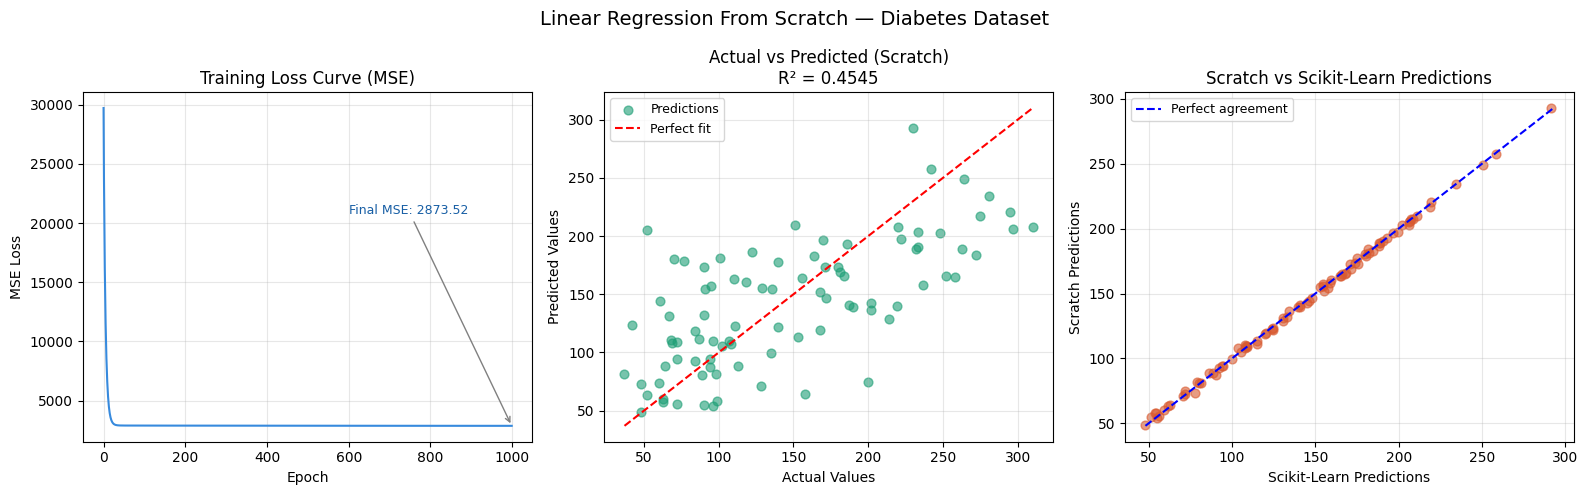


Plot saved as: linear_regression_results.png

Done!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Linear Regression From Scratch — Diabetes Dataset", fontsize=14)

# ── Plot 1: Training Loss Curve ───────────────
axes[0].plot(model.losses, color="#378ADD", linewidth=1.5)
axes[0].set_title("Training Loss Curve (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)
axes[0].annotate(
    f"Final MSE: {model.losses[-1]:.2f}",
    xy=(len(model.losses)-1, model.losses[-1]),
    xytext=(len(model.losses)*0.6, model.losses[0]*0.7),
    arrowprops=dict(arrowstyle="->", color="gray"),
    fontsize=9, color="#185FA5"
)

# ── Plot 2: Actual vs Predicted (Our Model) ───
axes[1].scatter(y_test, y_pred_scratch, alpha=0.6, color="#1D9E75", s=40, label="Predictions")
min_val = min(y_test.min(), y_pred_scratch.min())
max_val = max(y_test.max(), y_pred_scratch.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label="Perfect fit")
axes[1].set_title(f"Actual vs Predicted (Scratch)\nR² = {r2_scratch:.4f}")
axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# ── Plot 3: Scratch vs Sklearn Predictions ────
axes[2].scatter(y_pred_sklearn, y_pred_scratch, alpha=0.6, color="#D85A30", s=40)
min_val = min(y_pred_sklearn.min(), y_pred_scratch.min())
max_val = max(y_pred_sklearn.max(), y_pred_scratch.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'b--', linewidth=1.5, label="Perfect agreement")
axes[2].set_title("Scratch vs Scikit-Learn Predictions")
axes[2].set_xlabel("Scikit-Learn Predictions")
axes[2].set_ylabel("Scratch Predictions")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("linear_regression_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved as: linear_regression_results.png")
print("\nDone!")